![digitizing_team](digitizing_team.png)


DigiNsure Inc. is an innovative insurance company focused on enhancing the efficiency of processing claims and customer service interactions. Their newest initiative is digitizing all historical insurance claim documents, which includes improving the labeling of some IDs scanned from paper documents and identifying them as primary or secondary IDs.

To help them in their effort, you'll be using multi-modal learning to train an Optical Character Recognition (OCR) model. To improve the classification, the model will use **images** of the scanned documents as input and their **insurance type** (home, life, auto, health, or other). Integrating different data modalities (such as image and text) enables the model to perform better in complex scenarios, helping to capture more nuanced information. The **labels** that the model will be trained to identify are of two types: a primary and a secondary ID, for each image-insurance type pair.

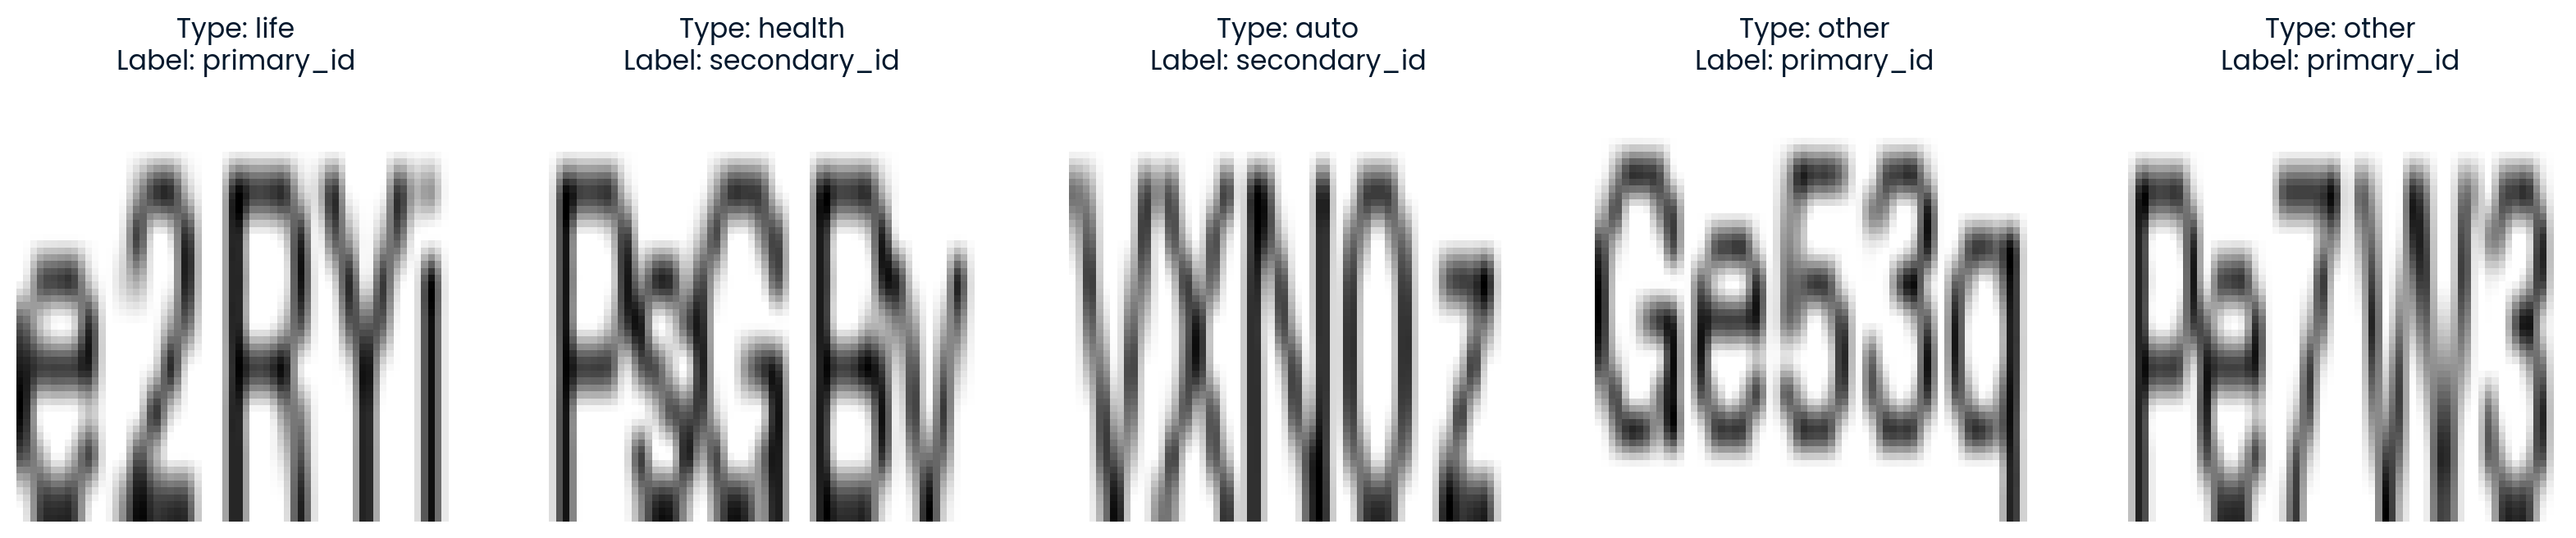

In [51]:
# Import the necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from project_utils import ProjectDataset
import pickle 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Load the data
dataset = pickle.load(open('ocr_insurance_dataset.pkl', 'rb'))

# Define a function to visualize codes with their corresponding types and labels 
def show_dataset_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, min(num_images, len(dataset)), figsize=(20, 4))
    for ax, idx in zip(axes, np.random.choice(len(dataset), min(num_images, len(dataset)), False)):
        img, lbl = dataset[idx]
        ax.imshow((img[0].numpy() * 255).astype(np.uint8).reshape(64,64), cmap='gray'), ax.axis('off')
        ax.set_title(f"Type: {list(dataset.type_mapping.keys())[img[1].tolist().index(1)]}\nLabel: {list(dataset.label_mapping.keys())[list(dataset.label_mapping.values()).index(lbl)]}")
    plt.show()

# Inspect 5 codes images from the dataset
show_dataset_images(dataset)

In [52]:
caminho_do_arquivo = 'ocr_insurance_dataset.pkl'

with open(caminho_do_arquivo, 'rb') as file:
    carga_bruta = pickle.load(file)

In [53]:
print("=" * 60)
print(" RECONSTRUINDO A MATRIZ DE DADOS (DATAFRAME) ")
print("=" * 60)

# 1. Desempacotando a Carga Útil
# Sabemos pelos nossos diagnósticos anteriores que carga_bruta.data 
# é uma lista de tuplas no formato: (matriz_da_imagem, id_do_tipo_de_seguro)
imagens_brutas = [amostra[0] for amostra in carga_bruta.data]
tipos_de_seguro = [amostra[1] for amostra in carga_bruta.data]

# O alvo preditivo (Primário vs Secundário) está em uma lista separada
labels_alvo = carga_bruta.labels

# 2. Forjando o DataFrame
# Alinhamos as três estruturas em uma matriz coesa que a nossa classe 
# LeanFusionDataset foi programada para ler.
df = pd.DataFrame({
    'imagem_matriz': imagens_brutas,
    'seguro_tipo_id': tipos_de_seguro,
    'label_id': labels_alvo
})

print(f"[+] Integridade estrutural restaurada. Dimensões do DataFrame: {df.shape}")
display(df.head(3))
print("=" * 60)

  RECONSTRUINDO A MATRIZ DE DADOS (DATAFRAME) 
[+] Integridade estrutural restaurada. Dimensões do DataFrame: (100, 3)


,imagem_matriz,seguro_tipo_id,label_id
0,"[[[tensor(1.), tensor(1.), tensor(1.), tensor(...","[tensor(1.), tensor(0.), tensor(0.), tensor(0....",0
1,"[[[tensor(1.), tensor(1.), tensor(1.), tensor(...","[tensor(1.), tensor(0.), tensor(0.), tensor(0....",1
2,"[[[tensor(1.), tensor(1.), tensor(1.), tensor(...","[tensor(1.), tensor(0.), tensor(0.), tensor(0....",1


In [54]:
class LeanFusionDataset(Dataset):
    def __init__(self, dataframe, transform):
        # Usamos .values (NumPy array bruto) em vez de DataFrame para leitura hiper-rápida no getitem
        self.data = dataframe[['imagem_matriz', 'seguro_tipo_id', 'label_id']].values
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Desempacotamento limpo, estilo Omniglot
        img_array, seguro_id, label = self.data[idx]
        
        # O transform faz o trabalho pesado (converte array -> PIL -> Tensor)
        img_tensor = self.transform(img_array)
        
        # Retornamos os tensores tipados corretamente para a fusão
        return img_tensor, torch.tensor(seguro_id, dtype=torch.long), torch.tensor(label, dtype=torch.float32)

In [55]:
import torchvision.transforms as transforms

print("=" * 60)
print(" RESTAURANDO CALIBRAGEM ÓPTICA (TRANSFORMS) ")
print("=" * 60)

# O Pipeline de Transformação: A ponte entre o caos do arquivo e a ordem da GPU
transformacoes_base = transforms.Compose([
    # 1. A Ponte: Puxa a matriz bruta e converte em imagem manipulável
    transforms.ToPILImage(),
    
    # 2. A Restrição da Corporação: Redimensionamento estrito para 64x64
    transforms.Resize((64, 64)),
    
    # 3. A Criptografia: Converte a imagem [0 a 255] em um Tensor [0.0 a 1.0]
    transforms.ToTensor(),
    
    # 4. Normalização monocromática: apenas 1 média e 1 desvio padrão
    transforms.Normalize(mean=[0.5], std=[0.5])
])

print("[+] Lentes de Visão Computacional recalibradas e ativas na memória.")

  RESTAURANDO CALIBRAGEM ÓPTICA (TRANSFORMS) 
[+] Lentes de Visão Computacional recalibradas e ativas na memória.


In [56]:
print("=" * 60)
print(" INICIANDO PROTOCOLO DE ROTEAMENTO (DATALOADER) ")
print("=" * 60)

# 1. Instanciando o Dataset com as lentes calibradas
# Lembre-se: 'transformacoes_base' deve conter o Resize(64, 64) conforme o escopo exige
dataset_otimizado = LeanFusionDataset(
    dataframe=df, 
    transform=transformacoes_base
)

# 2. Configurando o Motor de Lotes (O Conduit)
# Tamanho do Lote (batch_size): Quantas amostras a rede processa por vez. 
# Como temos 100 amostras, lotes de 16 ou 20 são taticamente perfeitos.
tamanho_do_lote = 16

dataloader = DataLoader(
    dataset_otimizado, 
    batch_size=tamanho_do_lote, 
    shuffle=True,       # Injeta caos na ordem de leitura (previne vícios da rede)
    num_workers=2,      # Utiliza 2 núcleos da CPU em paralelo para não criar gargalos
    drop_last=False     # Garante que as últimas amostras não sejam descartadas se o lote for incompleto
)

print(f"[+] Roteador online. {len(dataloader)} lotes engatilhados por época.")
print("=" * 60)

  INICIANDO PROTOCOLO DE ROTEAMENTO (DATALOADER) 
[+] Roteador online. 7 lotes engatilhados por época.


In [57]:
class OCRModel(nn.Module):
    """
    Arquitetura Blackwall enxuta para OCR e classificação de IDs.
    Cumpre estritamente as diretrizes de 64x64 e nomenclatura do escopo.
    """
    def __init__(self, num_insurance_types=5):
        super(OCRModel, self).__init__()
        
        # ==========================================
        # Módulo de Visão (Obrigatório: 'image_layer')
        # Entrada esperada: [Batch, 3 canais, 64, 64]
        # ==========================================
        self.image_layer = nn.Sequential(
            # A camada exigida: Conv2d, kernel 3x3, padding 1
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Reduz a imagem para 32x32
            
            # Segunda camada para extrair padrões de OCR mais profundos
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Reduz a imagem para 16x16
            
            # Achatando para conectar com a camada densa (32 canais * 16 * 16 = 8192)
            nn.Flatten() 
        )
        
        # ==========================================
        # O Ponto de Fusão e Classificação
        # ==========================================
        self.classifier = nn.Sequential(
            nn.Linear(8197, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1) # Saída binária (Primário vs Secundário)
        )

    def forward(self, image, insurance_type):
        # Extrai features
        img_features = self.image_layer(image)

        # Forçamos o tensor a achatar qualquer dimensão extra, cravando-o em [Batch, 16]
        type_features = insurance_type.view(insurance_type.size(0), -1).float()
        
        # Funde as modalidades
        combined = torch.cat((img_features, type_features), dim=1)
        
        # Retorna os logits
        output = self.classifier(combined)
        return output.squeeze(1)

print("[+] OCRModel compilado e carregado na memória.")

[+] OCRModel compilado e carregado na memória.


In [59]:
print("=" * 60)
print(" INICIANDO PROTOCOLO DE APRENDIZADO DE MÁQUINA ")
print("=" * 60)

# 1. Instanciando o modelo
model = OCRModel()

# Movemos o modelo para a GPU, se a plataforma tiver uma disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f'DEVICE - {device}')

# 2. Definindo a Perda e o Otimizador
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. O Loop de Treinamento (10 Épocas)
num_epochs = 10

# Nota: Estou assumindo que o seu DataLoader se chama 'dataloader'
# conforme configuramos nos passos anteriores.

model.train() # Coloca a rede em modo de aprendizado

for epoch in range(num_epochs):
    loss_acumulada = 0.0
    
    # Itera sobre os lotes de dados
    for batch_images, batch_types, batch_labels in dataloader:
        
        # Sincronizando dados com o hardware correto (CPU/GPU)
        batch_images = batch_images.to(device)
        batch_types = batch_types.to(device)
        batch_labels = batch_labels.to(device)
        
        # Zera os gradientes residuais do ciclo anterior
        optimizer.zero_grad()
        
        # Forward pass: A rede tenta prever os resultados
        previsoes = model(batch_images, batch_types)
        
        # Calcula o erro (Loss) comparando previsão vs realidade
        loss = criterion(previsoes, batch_labels)
        
        # Backward pass: A rede descobre onde errou (Backpropagation)
        loss.backward()
        
        # Optimizer step: Ajusta os pesos neurais
        optimizer.step()
        
        loss_acumulada += loss.item()
        
    # Métrica de telemetria ao final de cada época
    media_loss_epoca = loss_acumulada / len(dataloader)
    print(f"[+] Época {epoch+1}/{num_epochs} concluída | Loss: {media_loss_epoca:.4f}")

print("-" * 60)
print(" Treinamento finalizado. A rede está calibrada.")

  INICIANDO PROTOCOLO DE APRENDIZADO DE MÁQUINA 
DEVICE - cpu
[+] Época 1/10 concluída | Loss: 0.7072
[+] Época 2/10 concluída | Loss: 0.6758
[+] Época 3/10 concluída | Loss: 0.6614
[+] Época 4/10 concluída | Loss: 0.6070
[+] Época 5/10 concluída | Loss: 0.5256
[+] Época 6/10 concluída | Loss: 0.5219
[+] Época 7/10 concluída | Loss: 0.3499
[+] Época 8/10 concluída | Loss: 0.3050
[+] Época 9/10 concluída | Loss: 0.2755
[+] Época 10/10 concluída | Loss: 0.3019
------------------------------------------------------------
 Treinamento finalizado. A rede está calibrada.
